<a href="https://colab.research.google.com/github/VioletLiu0620/deeplearning/blob/main/practices/04_pytorch_custom_datasets_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 04. PyTorch Custom Datasets Exercises Template

Welcome to the 04. PyTorch Custom Datasets exercise template.

The best way to practice PyTorch code is to write more PyTorch code.

So read the original notebook and try to complete the exercises by writing code where it's required.

Feel free to reference the original resources whenever you need but should practice writing all of the code yourself.

## Resources

1. These exercises/solutions are based on [notebook 04 of the Learn PyTorch for Deep Learning course](https://www.learnpytorch.io/04_pytorch_custom_datasets/).
2. See a live [walkthrough of the solutions (errors and all) on YouTube](https://youtu.be/vsFMF9wqWx0).
3. See [other solutions on the course GitHub](https://github.com/mrdbourke/pytorch-deep-learning/tree/main/extras/solutions).

In [3]:
# Check for GPU
!nvidia-smi

Wed Aug  5 09:53:25 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
# Import torch
import torch
from torch import nn

# Exercises require PyTorch > 1.10.0
print(torch.__version__)

# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

2.11.0+cu128


'cuda'

## 1. Our models are underperforming (not fitting the data well). What are 3 methods for preventing underfitting? Write them down and explain each with a sentence.

1. more epochs, training for longer to allow model to learn data patterns in a longer period of time and use the property of loss backward to improve parameters for them to better suit the data.
2. higher learnin rate, this depends on the optimizer used, some optimizers like Adam might perform better with 0.001 instead of 0.01 or 0.0001, but other optimizers, higher lr might learn faster.
3. more hidden units to add on complexity of the overall model, to learn generalizeable patterns in training data
4. use transfer learning such as ResNet or VGG16 trained on ImageNet to leverage previous find patterns and apply them to the next stage of learning

## 2. Recreate the data loading functions we built in [sections 1, 2, 3 and 4 of notebook 04](https://www.learnpytorch.io/04_pytorch_custom_datasets/). You should have train and test `DataLoader`'s ready to use.

In [5]:
# 1. Get data
import requests
import zipfile
from pathlib import Path

# Setup path
data_path = Path("data")
image_path = data_path / "pizza_steak_sushi"

if not image_path.is_dir():
  image_path.mkdir(parents=True, exist_ok=True)
else:
  print(f"File already exist")

with open(data_path / "pizza_steak_sushi.zip", "wb") as f:
  request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/refs/heads/main/data/pizza_steak_sushi.zip")
  print(f"Downloading file to {image_path}...")
  f.write(request.content)

# Unzip the zip files
with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip_ref:
  print(f"Unzip files")
  zip_ref.extractall(image_path)

Unzip files


In [6]:
# 2. Become one with the data
import os
def walk_through_dir(dir_path):
  """Walks through dir_path returning file counts of its contents."""
  for dirpath, dirnames, filenames in os.walk(dir_path):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

walk_through_dir(image_path)

There are 2 directories and 0 images in 'data/pizza_steak_sushi'.
There are 3 directories and 0 images in 'data/pizza_steak_sushi/train'.
There are 0 directories and 72 images in 'data/pizza_steak_sushi/train/sushi'.
There are 0 directories and 75 images in 'data/pizza_steak_sushi/train/steak'.
There are 0 directories and 78 images in 'data/pizza_steak_sushi/train/pizza'.
There are 3 directories and 0 images in 'data/pizza_steak_sushi/test'.
There are 0 directories and 31 images in 'data/pizza_steak_sushi/test/sushi'.
There are 0 directories and 19 images in 'data/pizza_steak_sushi/test/steak'.
There are 0 directories and 25 images in 'data/pizza_steak_sushi/test/pizza'.


In [7]:
# Setup train and testing paths
train_path = image_path / "train"
test_path = image_path / "test"

walk_through_dir(train_path)

There are 3 directories and 0 images in 'data/pizza_steak_sushi/train'.
There are 0 directories and 72 images in 'data/pizza_steak_sushi/train/sushi'.
There are 0 directories and 75 images in 'data/pizza_steak_sushi/train/steak'.
There are 0 directories and 78 images in 'data/pizza_steak_sushi/train/pizza'.


Image class: steak
Image height and width: 512 x 512


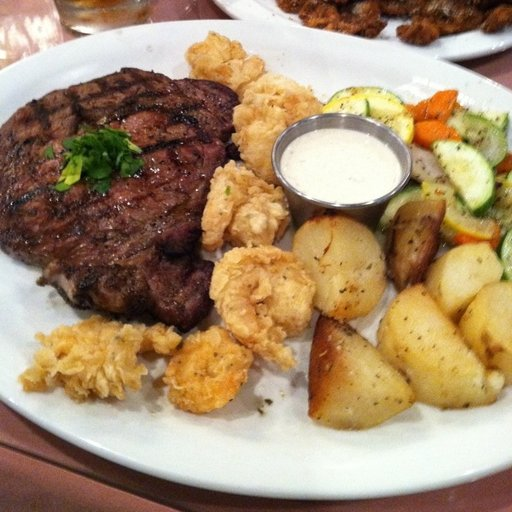

In [8]:
import random
from PIL import Image
from matplotlib import pyplot as plt

# Get all the image names using glob
all_image_list = list(image_path.glob("*/*/*.jpg"))

# Get a random image
random_image_path = random.choice(all_image_list)
random_image = Image.open(random_image_path)

# Get the class of this random image
random_image_class = random_image_path.parent.stem

# Visualize an image
print(f"Image class: {random_image_class}")
print(f"Image height and width: {random_image.height} x {random_image.width}")
random_image

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

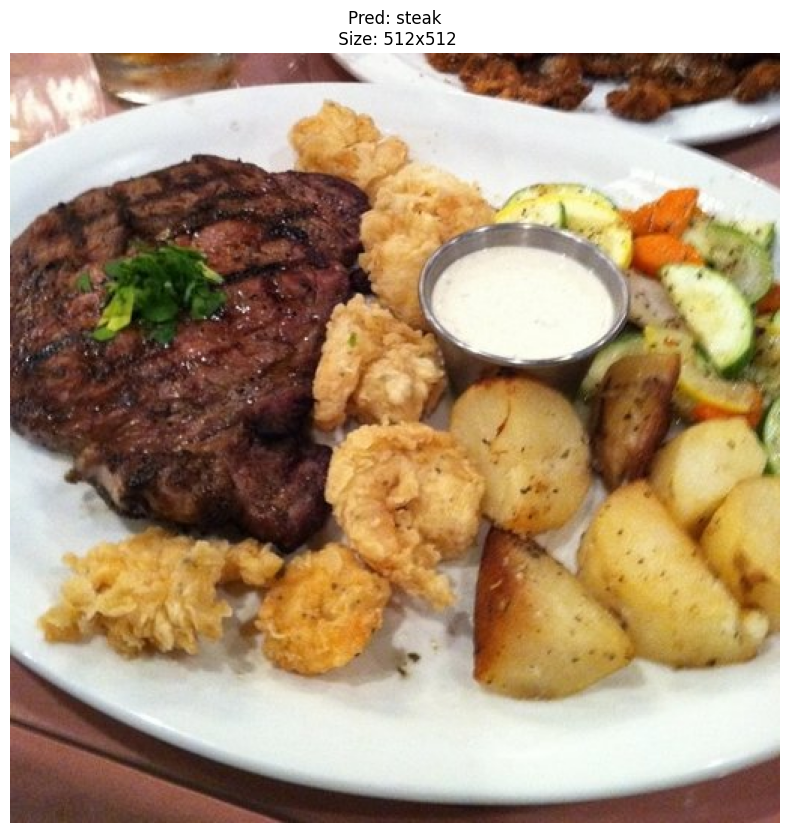

In [9]:
from torchvision import transforms

# Do the image visualization with matplotlib
PIL_to_tensor = transforms.Compose([transforms.PILToTensor()])
random_tensor_image = PIL_to_tensor(random_image)

plt.figure(figsize=(10,10))
plt.imshow(random_tensor_image.permute(1,2,0))
plt.title(f"Pred: {random_image_class}\n Size: {random_tensor_image.shape[1]}x{random_tensor_image.shape[2]}")
plt.axis(False)

We've got some images in our folders.

Now we need to make them compatible with PyTorch by:
1. Transform the data into tensors.
2. Turn the tensor data into a `torch.utils.data.Dataset` and later a `torch.utils.data.DataLoader`.

In [10]:
# 3.1 Transforming data with torchvision.transforms
train_dir = image_path / "train"
test_dir = image_path / "test"

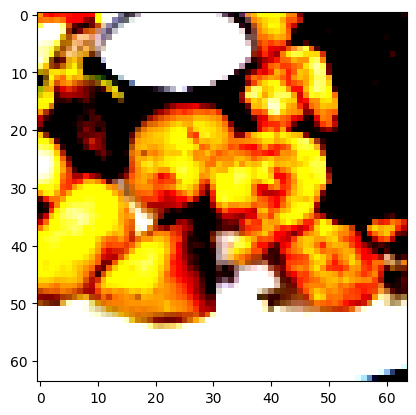

In [11]:
from torchvision.transforms import v2

# Write transform for turning images into tensors
image_transform = v2.Compose([v2.RandomResizedCrop(size=(64, 64), antialias=True),
                              v2.RandomHorizontalFlip(p=0.5),
                              v2.ToImage(),
                              v2.ToDtype(torch.float32, scale=True),
                              v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
                              ])

plt.imshow(image_transform(random_image).permute(1,2,0))

In [12]:
# Write transform for turning images into tensors
data_transform = transforms.Compose([
  # Resize the images to 64x64x3 (64 height, 64 width, 3 color channels)
  transforms.Resize(size=(64, 64)),
  # Flip the images randomly on horizontal
  transforms.RandomHorizontalFlip(p=0.5),
  # Turn the image into a torch.Tensor
  transforms.ToTensor() # converts all pixel values from 0-255 to be between 0-1
])

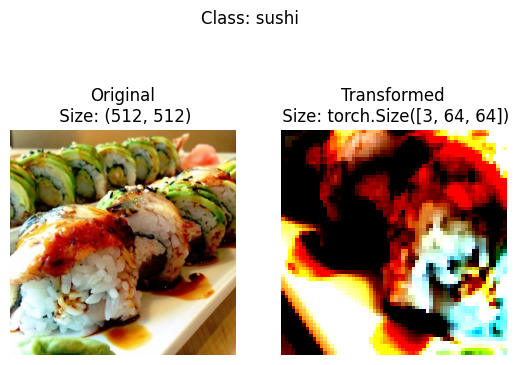

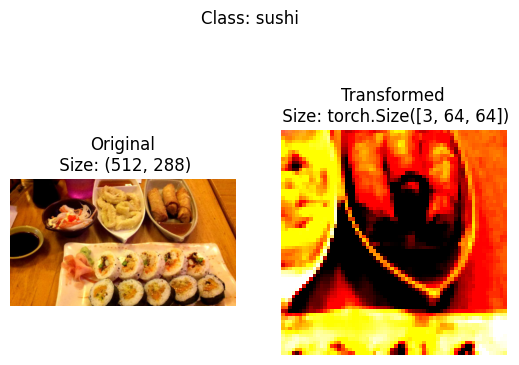

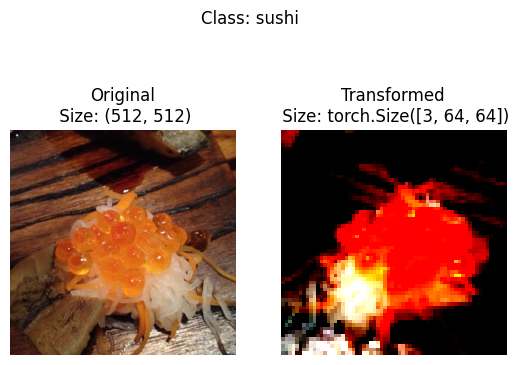

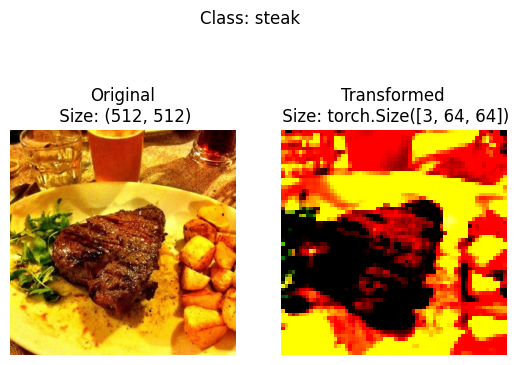

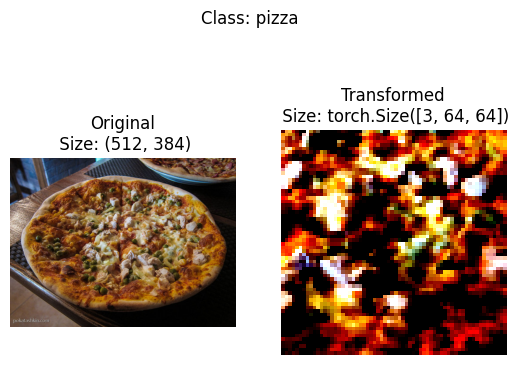

In [13]:
# Write a function to plot transformed images
def plot_transformed_image(image_path: list, transform, n=3, seed=None):
  if seed:
    torch.manual_seed(seed)
  random_image_paths = random.sample(image_path, k=n)

  for image_path in random_image_paths:
    with Image.open(image_path) as f:
      fig, ax = plt.subplots(nrows=1, ncols=2)

      ax[0].imshow(f)
      ax[0].set_title(f"Original\n Size: {f.size}")
      ax[0].axis(False)

      transformed = transform(f)

      ax[1].imshow(transformed.permute(1,2,0))
      ax[1].set_title(f"Transformed\n Size: {transformed.shape}")
      ax[1].axis(False)

      image_class = image_path.parent.stem
      fig.suptitle(f"Class: {image_class}")

plot_transformed_image(image_path= all_image_list, transform= image_transform, n=5, seed=42)

### Load image data using `ImageFolder`

In [14]:
# Use ImageFolder to create dataset(s)
from torch.utils.data import Dataset, DataLoader
from torchvision.datasets import ImageFolder

train_data = ImageFolder(root= train_dir,
                         transform= image_transform,
                         target_transform= None)

test_data = ImageFolder(root= test_dir,
                        transform= image_transform,
                        target_transform= None)

train_data.classes, train_data.class_to_idx, train_data.transform

(['pizza', 'steak', 'sushi'],
 {'pizza': 0, 'steak': 1, 'sushi': 2},
 Compose(
       RandomResizedCrop(size=(64, 64), scale=(0.08, 1.0), ratio=(0.75, 1.3333333333333333), interpolation=InterpolationMode.BILINEAR, antialias=True)
       RandomHorizontalFlip(p=0.5)
       ToImage()
       ToDtype(scale=True)
       Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], inplace=False)
 ))

In [15]:
# Get class names as a list
class_names = train_data.classes
class_names

['pizza', 'steak', 'sushi']

In [16]:
# Can also get class names as a dict
class_dict = train_data.class_to_idx
class_dict

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [17]:
# Check the lengths of each dataset
len(train_data), len(test_data)

(225, 75)

In [18]:
# Turn train and test Datasets into DataLoaders
import os
BATCH_SIZE = 1
NUM_WORKERS = 0

train_dataloader = DataLoader(dataset= train_data,
                              batch_size= BATCH_SIZE,
                              num_workers= NUM_WORKERS,
                              shuffle= True)

test_dataloader = DataLoader(dataset= test_data,
                              batch_size= BATCH_SIZE,
                              num_workers= NUM_WORKERS,
                              shuffle= False)

In [19]:
# How many batches of images are in our data loaders?
len(train_dataloader), len(test_dataloader)

(225, 75)

In [20]:
75/32

2.34375

## 3. Recreate `model_0` we built in section 7 of notebook 04.

In [21]:
from torch import nn

class TinyVGG(nn.Module):
  def __init__(self,
               input_shape: int,
               hidden_units: int,
               output_shape: int):
    super().__init__()
    self.stack = nn.Sequential(
      nn.Conv2d(in_channels= input_shape,
                out_channels= hidden_units,
                kernel_size= (3,3),
                stride= 1,
                padding= 1),
      nn.ReLU(),
      nn.Conv2d(in_channels= hidden_units,
                out_channels= hidden_units,
                kernel_size= (3,3),
                stride= 1,
                padding= 1),
      nn.ReLU(),
      nn.MaxPool2d(kernel_size= (2,2)),

      nn.Conv2d(in_channels= hidden_units,
                out_channels= hidden_units,
                kernel_size= (3,3),
                stride= 1,
                padding= 1),
      nn.ReLU(),
      nn.Conv2d(in_channels= hidden_units,
                out_channels= hidden_units,
                kernel_size= (3,3),
                stride= 1,
                padding= 1),
      nn.ReLU(),
      nn.MaxPool2d(kernel_size= (2,2)),

      nn.Flatten(),
      nn.Linear(in_features= hidden_units*16*16,
                out_features= output_shape)
    )
  def forward(self, x):
    return self.stack(x)

In [22]:
model_0 = TinyVGG(input_shape= 3,
                  hidden_units= 10,
                  output_shape= len(class_names)).to(device)
model_0, next(model_0.parameters()).device

(TinyVGG(
   (stack): Sequential(
     (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
     (1): ReLU()
     (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
     (3): ReLU()
     (4): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
     (5): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
     (6): ReLU()
     (7): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
     (8): ReLU()
     (9): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
     (10): Flatten(start_dim=1, end_dim=-1)
     (11): Linear(in_features=2560, out_features=3, bias=True)
   )
 ),
 device(type='cuda', index=0))

In [23]:
device

'cuda'

## 4. Create training and testing functions for `model_0`.

In [24]:
def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               device: torch.device = device):

  # Put the model in train mode
  model.train()

  # Setup train loss and train accuracy values
  train_loss, train_acc = 0, 0

  # Loop through data loader and data batches
  for batch, (X, y) in enumerate(dataloader):
    # Send data to target device
    X, y = X.to(device), y.to(device)

    # 1. Forward pass
    y_pred = model(X)

    # 2. Calculate and accumulate loss
    loss = loss_fn(y_pred, y)
    train_loss += loss.item()

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backward
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    # Calculate and accumualte accuracy metric across all batches
    y_label = torch.softmax(y_pred, dim=1).argmax(dim=1)

    train_acc += (y_label == y).sum().item() / len(y_label)

  # Adjust metrics to get average loss and average accuracy per batch
  avg_loss = train_loss / len(dataloader)
  avg_acc = train_acc / len(dataloader)

  return avg_loss, avg_acc

In [25]:
def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              device: torch.device = device):

  # Put model in eval mode
  model.eval()

  # Setup the test loss and test accuracy values
  test_loss, test_acc = 0, 0

  # Turn on inference context manager
  with torch.inference_mode():
    # Loop through DataLoader batches
    for X, y in dataloader:
      # Send data to target device
      X, y = X.to(device), y.to(device)

      # 1. Forward pass
      y_pred = model(X)

      # 2. Calculuate and accumulate loss
      loss = loss_fn(y_pred, y)
      test_loss += loss.item()

      # Calculate and accumulate accuracy
      y_label = torch.softmax(y_pred, dim=1).argmax(dim=1)
      test_acc += (y_label == y).sum().item() / len(y_pred)

  # Adjust metrics to get average loss and accuracy per batch
  avg_loss = test_loss / len(dataloader)
  avg_acc = test_acc / len(dataloader)

  return avg_loss, avg_acc

In [26]:
from tqdm.auto import tqdm

def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
          epochs: int = 5):

  # Create results dictionary
  results = {"train_loss": [],
             "train_acc": [],
             "test_loss": [],
             "test_acc": []}

  # Loop through the training and testing steps for a number of epochs
  for epoch in tqdm(range(epochs)):
    # Train step
    train_loss, train_acc = train_step(model=model,
                                       dataloader=train_dataloader,
                                       loss_fn=loss_fn,
                                       optimizer=optimizer)
    # Test step
    test_loss, test_acc = test_step(model=model,
                                    dataloader=test_dataloader,
                                    loss_fn=loss_fn)

    # Print out what's happening
    print(f"Epoch: {epoch+1} | "
          f"train_loss: {train_loss:.4f} | "
          f"train_acc: {train_acc:.4f} | "
          f"test_loss: {test_loss:.4f} | "
          f"test_acc: {test_acc:.4f}"
    )

    # Update the results dictionary
    results["train_loss"].append(train_loss)
    results["train_acc"].append(train_acc)
    results["test_loss"].append(test_loss)
    results["test_acc"].append(test_acc)

  # Return the results dictionary
  return results

## 5. Try training the model you made in exercise 3 for 5, 20 and 50 epochs, what happens to the results?
* Use `torch.optim.Adam()` with a learning rate of 0.001 as the optimizer.

In [27]:
# Train for 5 epochs
torch.manual_seed(42)
torch.cuda.manual_seed(42)

model_0_5 = TinyVGG(input_shape=3,
                    hidden_units=10,
                    output_shape=3).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_0_5.parameters(),
                             lr=0.001)

model_0_5_result = train(model= model_0_5,
                       train_dataloader= train_dataloader,
                       test_dataloader= test_dataloader,
                       optimizer= optimizer,
                       loss_fn= loss_fn,
                       epochs = 5)

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.0996 | train_acc: 0.3467 | test_loss: 1.1531 | test_acc: 0.4400
Epoch: 2 | train_loss: 1.0027 | train_acc: 0.5333 | test_loss: 1.0068 | test_acc: 0.4667
Epoch: 3 | train_loss: 0.9378 | train_acc: 0.5600 | test_loss: 1.1004 | test_acc: 0.4533
Epoch: 4 | train_loss: 0.9528 | train_acc: 0.5244 | test_loss: 1.0891 | test_acc: 0.3733
Epoch: 5 | train_loss: 0.9512 | train_acc: 0.5867 | test_loss: 1.0607 | test_acc: 0.4133


In [28]:
# Train for 20 epochs
torch.manual_seed(42)
torch.cuda.manual_seed(42)

model_0_20 = TinyVGG(input_shape=3,
                    hidden_units=10,
                    output_shape=3).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_0_20.parameters(),
                             lr=0.001)

model_0_20_result = train(model= model_0_20,
                       train_dataloader= train_dataloader,
                       test_dataloader= test_dataloader,
                       optimizer= optimizer,
                       loss_fn= loss_fn,
                       epochs = 20)

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.0997 | train_acc: 0.3467 | test_loss: 1.1533 | test_acc: 0.4400
Epoch: 2 | train_loss: 1.0011 | train_acc: 0.5156 | test_loss: 0.9975 | test_acc: 0.4667
Epoch: 3 | train_loss: 0.9814 | train_acc: 0.5778 | test_loss: 1.1367 | test_acc: 0.3867
Epoch: 4 | train_loss: 0.9534 | train_acc: 0.5378 | test_loss: 1.0637 | test_acc: 0.3733
Epoch: 5 | train_loss: 0.9435 | train_acc: 0.5911 | test_loss: 0.9985 | test_acc: 0.4667
Epoch: 6 | train_loss: 0.9117 | train_acc: 0.5644 | test_loss: 1.0623 | test_acc: 0.4533
Epoch: 7 | train_loss: 0.8514 | train_acc: 0.6356 | test_loss: 0.9933 | test_acc: 0.4800
Epoch: 8 | train_loss: 0.8946 | train_acc: 0.5867 | test_loss: 1.0987 | test_acc: 0.5067
Epoch: 9 | train_loss: 0.8524 | train_acc: 0.6311 | test_loss: 0.9929 | test_acc: 0.5333
Epoch: 10 | train_loss: 0.8251 | train_acc: 0.6400 | test_loss: 1.1320 | test_acc: 0.4133
Epoch: 11 | train_loss: 0.8495 | train_acc: 0.6444 | test_loss: 1.0731 | test_acc: 0.4267
Epoch: 12 | train_l

In [29]:
# Train for 50 epochs
torch.manual_seed(42)
torch.cuda.manual_seed(42)

model_0_50 = TinyVGG(input_shape=3,
                    hidden_units=10,
                    output_shape=3).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_0_50.parameters(),
                             lr=0.0005)

model_0_50_result = train(model= model_0_50,
                       train_dataloader= train_dataloader,
                       test_dataloader= test_dataloader,
                       optimizer= optimizer,
                       loss_fn= loss_fn,
                       epochs = 50)

  0%|          | 0/50 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.0775 | train_acc: 0.3867 | test_loss: 1.1263 | test_acc: 0.4133
Epoch: 2 | train_loss: 0.9613 | train_acc: 0.5333 | test_loss: 0.9756 | test_acc: 0.4933
Epoch: 3 | train_loss: 0.8916 | train_acc: 0.5778 | test_loss: 1.0827 | test_acc: 0.4800
Epoch: 4 | train_loss: 0.9154 | train_acc: 0.5333 | test_loss: 1.0442 | test_acc: 0.4000
Epoch: 5 | train_loss: 0.9006 | train_acc: 0.6089 | test_loss: 0.9859 | test_acc: 0.5200
Epoch: 6 | train_loss: 0.9051 | train_acc: 0.6089 | test_loss: 1.0749 | test_acc: 0.4667
Epoch: 7 | train_loss: 0.8368 | train_acc: 0.6089 | test_loss: 1.0308 | test_acc: 0.4667
Epoch: 8 | train_loss: 0.8775 | train_acc: 0.6178 | test_loss: 1.1413 | test_acc: 0.4800
Epoch: 9 | train_loss: 0.8355 | train_acc: 0.6311 | test_loss: 1.0220 | test_acc: 0.5467
Epoch: 10 | train_loss: 0.8034 | train_acc: 0.6400 | test_loss: 1.1810 | test_acc: 0.4533
Epoch: 11 | train_loss: 0.8630 | train_acc: 0.6089 | test_loss: 1.0921 | test_acc: 0.3733
Epoch: 12 | train_l

It looks like our model is starting to overfit towards the end (performing far better on the training data than on the testing data).

In order to fix this, we'd have to introduce ways of preventing overfitting.

## 6. Double the number of hidden units in your model and train it for 20 epochs, what happens to the results?

In [30]:
# Double the number of hidden units and train for 20 epochs
torch.manual_seed(42)
torch.cuda.manual_seed(42)


model_0_e20_h20 = TinyVGG(input_shape=3,
                    hidden_units=20,
                    output_shape=3).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_0_e20_h20.parameters(),
                             lr=0.001)

model_0_e20_h20_result = train(model= model_0_e20_h20,
                       train_dataloader= train_dataloader,
                       test_dataloader= test_dataloader,
                       optimizer= optimizer,
                       loss_fn= loss_fn,
                       epochs = 20)

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.0230 | train_acc: 0.4711 | test_loss: 1.0288 | test_acc: 0.4133
Epoch: 2 | train_loss: 0.9824 | train_acc: 0.5156 | test_loss: 1.0230 | test_acc: 0.5733
Epoch: 3 | train_loss: 0.9503 | train_acc: 0.5556 | test_loss: 0.9882 | test_acc: 0.4267
Epoch: 4 | train_loss: 0.9295 | train_acc: 0.6089 | test_loss: 1.1470 | test_acc: 0.4667
Epoch: 5 | train_loss: 0.9388 | train_acc: 0.5733 | test_loss: 0.9329 | test_acc: 0.5467
Epoch: 6 | train_loss: 0.8529 | train_acc: 0.5822 | test_loss: 1.1752 | test_acc: 0.4533
Epoch: 7 | train_loss: 0.8754 | train_acc: 0.6044 | test_loss: 0.9809 | test_acc: 0.4667
Epoch: 8 | train_loss: 0.8742 | train_acc: 0.6178 | test_loss: 0.9643 | test_acc: 0.5467
Epoch: 9 | train_loss: 0.8998 | train_acc: 0.6311 | test_loss: 0.9624 | test_acc: 0.5467
Epoch: 10 | train_loss: 0.9228 | train_acc: 0.5778 | test_loss: 0.9690 | test_acc: 0.5600
Epoch: 11 | train_loss: 0.8726 | train_acc: 0.5689 | test_loss: 0.9662 | test_acc: 0.5067
Epoch: 12 | train_l

It looks like the model is still overfitting, even when changing the number of hidden units.

To fix this, we'd have to look at ways to prevent overfitting with our model.

## 7. Double the data you're using with your model from step 6 and train it for 20 epochs, what happens to the results?
* **Note:** You can use the [custom data creation notebook](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/extras/04_custom_data_creation.ipynb) to scale up your Food101 dataset.
* You can also find the [already formatted double data (20% instead of 10% subset) dataset on GitHub](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/data/pizza_steak_sushi_20_percent.zip), you will need to write download code like in exercise 2 to get it into this notebook.

In [31]:
# Download 20% data for Pizza/Steak/Sushi from GitHub
import requests
import zipfile
from pathlib import Path

# Setup path to data folder
data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi_20_percent"

# If the image folder doesn't exist, download it and prepare it...
if image_path.is_dir():
    print(f"{image_path} directory exists.")
else:
    print(f"Did not find {image_path} directory, creating one...")
    image_path.mkdir(parents=True, exist_ok=True)

# Download pizza, steak, sushi data
with open(data_path / "pizza_steak_sushi_20_percent.zip", "wb") as f:
    request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi_20_percent.zip")
    print("Downloading pizza, steak, sushi 20% data...")
    f.write(request.content)

# Unzip pizza, steak, sushi data
with zipfile.ZipFile(data_path / "pizza_steak_sushi_20_percent.zip", "r") as zip_ref:
    print("Unzipping pizza, steak, sushi 20% data...")
    zip_ref.extractall(image_path)

Did not find data/pizza_steak_sushi_20_percent directory, creating one...
Unzipping pizza, steak, sushi 20% data...


In [32]:
# See how many images we have
walk_through_dir(image_path)

There are 2 directories and 0 images in 'data/pizza_steak_sushi_20_percent'.
There are 3 directories and 0 images in 'data/pizza_steak_sushi_20_percent/train'.
There are 0 directories and 150 images in 'data/pizza_steak_sushi_20_percent/train/sushi'.
There are 0 directories and 146 images in 'data/pizza_steak_sushi_20_percent/train/steak'.
There are 0 directories and 154 images in 'data/pizza_steak_sushi_20_percent/train/pizza'.
There are 3 directories and 0 images in 'data/pizza_steak_sushi_20_percent/test'.
There are 0 directories and 46 images in 'data/pizza_steak_sushi_20_percent/test/sushi'.
There are 0 directories and 58 images in 'data/pizza_steak_sushi_20_percent/test/steak'.
There are 0 directories and 46 images in 'data/pizza_steak_sushi_20_percent/test/pizza'.


Excellent, we now have double the training and testing images...

In [143]:
# Create the train and test paths
train_data_20_percent_path = image_path / "train"
test_data_20_percent_path = image_path / "test"

train_data_20_percent_path, test_data_20_percent_path

(PosixPath('data/pizza_steak_sushi_20_percent/train'),
 PosixPath('data/pizza_steak_sushi_20_percent/test'))

In [147]:
# Turn the 20 percent datapaths into Datasets and DataLoaders
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch.utils.data import DataLoader

# simple_transform = transforms.Compose([
#   transforms.Resize((64, 64)),
#   transforms.ToTensor()
# ])

simple_transform = v2.Compose([
    v2.Resize((64, 64)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),  # ← MATCH train
])

# Create datasets
train_data_20_percent = ImageFolder(root= train_data_20_percent_path,
                                    transform= image_transform)
test_data_20_percent = ImageFolder(root= test_data_20_percent_path,
                                   transform= simple_transform)

BATCH_SIZE = 8

# Create dataloaders
train_dataloader_20_percent = DataLoader(dataset= train_data_20_percent,
                                         batch_size= BATCH_SIZE,
                                         num_workers= 0,
                                         shuffle= True)
test_dataloader_20_percent = DataLoader(dataset= test_data_20_percent,
                                         batch_size= BATCH_SIZE,
                                         num_workers= 0,
                                        shuffle= False)

In [148]:
# Train a model with increased amount of data
torch.manual_seed(42)
torch.cuda.manual_seed(42)

model_4 = TinyVGG(input_shape=3,
                  hidden_units=20,
                  output_shape=len(class_names)).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_4.parameters(), lr=0.0012)

model_4_results = train(model=model_4,
                        train_dataloader=train_dataloader_20_percent, # use double the training data
                        test_dataloader=test_dataloader_20_percent, # use double the testing data
                        optimizer=optimizer,
                        epochs=50) # train for 20 epochs

  0%|          | 0/50 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.0432 | train_acc: 0.4759 | test_loss: 0.9661 | test_acc: 0.4693
Epoch: 2 | train_loss: 0.9957 | train_acc: 0.4890 | test_loss: 1.0120 | test_acc: 0.4101
Epoch: 3 | train_loss: 0.9838 | train_acc: 0.5197 | test_loss: 0.9890 | test_acc: 0.5461
Epoch: 4 | train_loss: 0.9407 | train_acc: 0.5789 | test_loss: 0.8956 | test_acc: 0.5548
Epoch: 5 | train_loss: 0.9670 | train_acc: 0.5329 | test_loss: 0.8726 | test_acc: 0.6009
Epoch: 6 | train_loss: 0.9324 | train_acc: 0.5395 | test_loss: 0.8706 | test_acc: 0.5482
Epoch: 7 | train_loss: 0.8738 | train_acc: 0.6009 | test_loss: 0.8413 | test_acc: 0.5987
Epoch: 8 | train_loss: 0.9484 | train_acc: 0.5570 | test_loss: 0.8303 | test_acc: 0.5899
Epoch: 9 | train_loss: 0.8941 | train_acc: 0.6162 | test_loss: 0.8731 | test_acc: 0.6053
Epoch: 10 | train_loss: 0.8645 | train_acc: 0.6184 | test_loss: 0.8201 | test_acc: 0.6031
Epoch: 11 | train_loss: 0.9027 | train_acc: 0.5768 | test_loss: 0.9456 | test_acc: 0.5702
Epoch: 12 | train_l

In [149]:
# Plot the model result
def plot_result(result: dict, title: str):
  plt.figure(figsize=(16,5))

  train_loss = result["train_loss"]
  train_acc = result["train_acc"]
  test_loss = result["test_loss"]
  test_acc = result["test_acc"]
  epochs = range(len(result["train_loss"]))

  plt.subplot(1,2,1)
  plt.plot(epochs, train_loss, label="train loss")
  plt.plot(epochs, test_loss, label="test loss")
  plt.title("Loss")
  plt.xlabel("Epochs")
  plt.ylabel("Loss")
  plt.legend()

  plt.subplot(1,2,2)
  plt.plot(epochs, train_acc, label="train acc")
  plt.plot(epochs, test_acc, label="test acc")
  plt.title("Accuracy")
  plt.xlabel("Epochs")
  plt.ylabel("Accuracy (%)")
  plt.legend()

  plt.suptitle(f"Result: {title}")

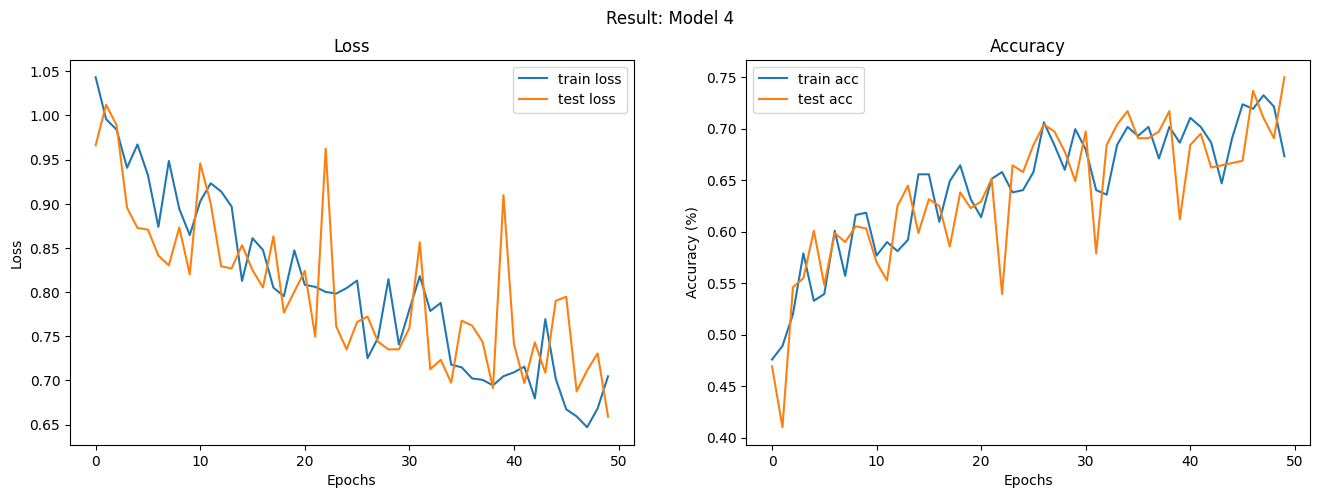

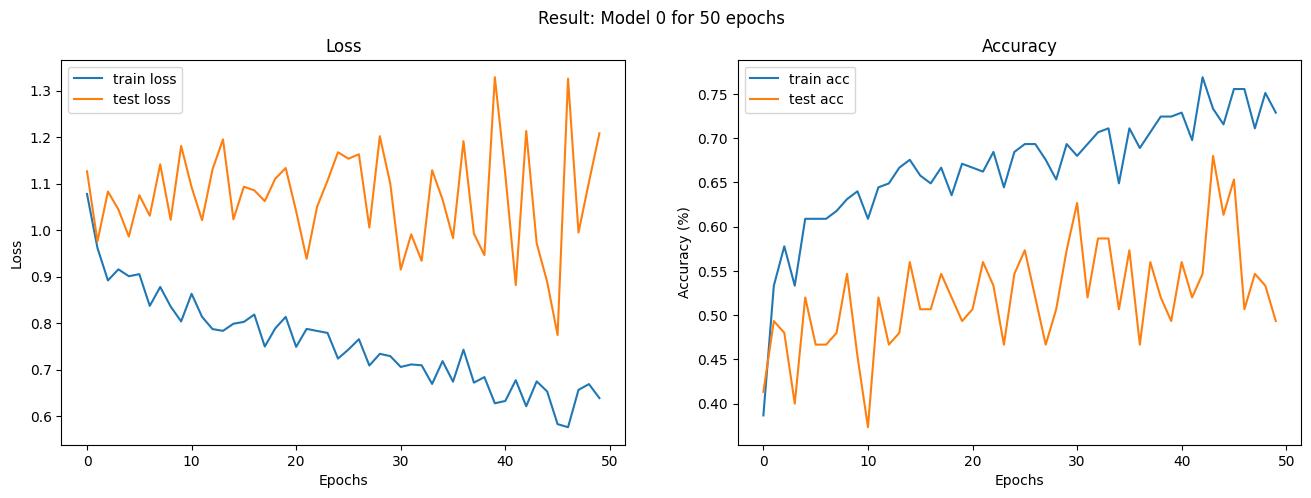

In [150]:
plot_result(model_4_results, "Model 4")
plot_result(model_0_50_result, "Model 0 for 50 epochs")

## 8. Make a prediction on your own custom image of pizza/steak/sushi (you could even download one from the internet) with your trained model from exercise 7 and share your prediction.
* Does the model you trained in exercise 7 get it right?
* If not, what do you think you could do to improve it?

In [99]:
import requests

with open(data_path / "custom_sushi_pic.png", "wb") as f:
  request = requests.get("https://github.com/VioletLiu0620/deeplearning/blob/main/custom_sushi_pic.png?raw=true")
  print(f"Downloading...")
  f.write(request.content)

Downloading...


In [151]:
model_4.eval()

custom_image_path = data_path / "custom_sushi_pic.png"

custom_image = Image.open(custom_image_path)

custom_image_data = data_transform(custom_image)

custom_image_data_RGB = custom_image_data[:3, :, :]

custom_image_data_RGB.shape

torch.Size([3, 64, 64])

Text(0.5, 1.0, 'custom_sushi_pic')

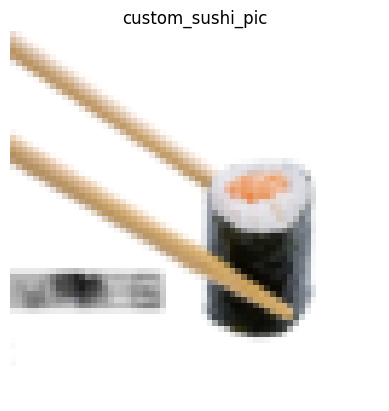

In [152]:
plt.imshow(custom_image_data_RGB.cpu().permute(1,2,0))
plt.axis(False)
plt.title(custom_image_path.stem)

In [153]:
model_4.eval()

with torch.inference_mode():
  custom_image_data_RGB = custom_image_data_RGB.to(device)

  y_logits = model_4(custom_image_data_RGB.unsqueeze(dim=0))

  y_label = torch.softmax(y_logits, dim=1).argmax(dim=1)

  print(f"Predict this image as class of {class_names[y_label]}")

Predict this image as class of steak
